# Categorical AR-HMM on zebrafish chemotaxis bouts

## Model

Two-level generative model:

| Level | Variable | Description |
|-------|----------|-------------|
| Outer | $z_t$ | Behavioral mode — slow, **latent** |
| Obs   | $c_t$ | Syllable type — fast, **observed**; transition dynamics are mode-specific |

**Generative story** for each bout $t$:
1. Transition behavioral mode: $z_t \mid z_{t-1} \sim A^{\text{out}}[z_{t-1}, :]$
2. Transition syllable: $c_t \mid c_{t-1},\, z_t \sim A^{\text{in}}_{z_t}[c_{t-1}, :]$

$A^{\text{in}}_{z_t}$ is a $K_{\text{obs}} \times K_{\text{obs}}$ syllable transition matrix specific to mode $z_t$. The mode **switches the Markov dynamics** of the observed syllable sequence — this is the discrete analogue of a **switching linear dynamical system (sLDS)**: $z_t$ is the switch variable and $A^{\text{in}}_{z_t}$ encodes mode-specific dynamics, but here the observations are categorical (syllable labels) rather than continuous.

You could also test whether outer transitions depend on the pH value — fish in the acid zone may be more likely to enter an escape mode. SSM implements this as a log-linear model with learned input weights $W \in \mathbb{R}^{K_{\text{out}}}$:

$$\log P(z_t = k \mid z_{t-1} = j,\, u_t) \propto \log A^{\text{out}}[j, k] + u_t \, W_k$$

Setting $u_t = 0$ recovers the standard HMM.

## Fitting (EM)

Parameters $\{A^{\text{out}}, A^{\text{in}}_k, W\}$ are learned with the Expectation–Maximisation algorithm:
- **E-step**: forward–backward gives the posterior $\gamma_t(k) = P(z_t = k \mid c_{1:T},\, u_{1:T})$
- **M-step**: $A^{\text{out}}$ and $W$ from expected transition counts; $A^{\text{in}}_k$ from syllable transitions weighted by $\gamma_t(k)$

SSM handles the outer HMM (forward–backward, Viterbi, input-driven transitions) but has no built-in categorical AR observation model. We therefore subclass `ssm.observations.Observations` and implement two methods:
- `log_likelihoods(data, ...)` — returns the $(T \times K_{\text{out}})$ matrix $\ell_t(z) = \log A^{\text{in}}_z[c_{t-1}, c_t]$ used in the E-step
- `m_step(expectations, ...)` — updates $A^{\text{in}}_z$ from the weighted syllable transition counts produced by the E-step

## Pipeline
1. Load Reddy et al. chemotaxis data and compute tail segment angles
2. Extract kinematic summary features per bout and cluster into $K_\text{obs}$ syllable types
3. Build per-fish bout sequence + input signal
4. Fit the categorical AR-HMM
5. Evaluate and compare gradient vs. no-gradient sessions

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import ssm
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from ssm.observations import Observations
from itertools import permutations as _perms

In [29]:
plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})

data_root       = Path('/Users/heike/Dropbox/BAMB_module5/Data_all')
arena_len_mm    = 140.0
gradient_len_mm = 20.0
fps             = 160

# ── custom observation class (categorical AR: P(c_t | c_{t-1}, z_t) = A_in[z_t, c_{t-1}, c_t]) ──
class CategoricalARObservations(Observations):
    def __init__(self, K, D, M=0, C=2):
        super().__init__(K, D, M)
        self.C = C
        self.logAs = np.full((K, C, C), -np.log(C))

    @property
    def params(self):
        return (self.logAs,)

    @params.setter
    def params(self, value):
        self.logAs, = value

    def initialize(self, datas, inputs=None, masks=None, tags=None, **kwargs):
        self.logAs = np.log(
            np.array([[np.random.dirichlet(np.ones(self.C))
                       for _ in range(self.C)] for _ in range(self.K)]) + 1e-8
        )

    def log_likelihoods(self, data, input, mask, tag):
        """
        Return (T, K) array of per-state log-likelihoods.

        For t = 0 : uniform log-likelihood -log(C) for all states.
        For t > 0 : log A_in[k, c[t-1], c[t]]  for each mode k.

        Hint: self.logAs has shape (K, C, C).
              self.logAs[:, c[:-1], c[1:]] selects the right entry for every
              timestep at once and gives shape (K, T-1) — transpose to (T-1, K).
        """
        c = data[:, 0].astype(int)
        lls = np.full((len(c), self.K), -np.log(self.C))   # t=0: uniform
        # ── YOUR CODE HERE ────────────────────────────────────────────────────
        # lls[1:] = ...
        return lls

    def sample(self, z, input=None, tag=None, with_noise=True):
        C, T = self.C, len(z)
        c = np.zeros(T, int)
        c[0] = np.random.choice(C)
        for t in range(1, T):
            p = np.exp(self.logAs[z[t], c[t-1]])
            c[t] = np.random.choice(C, p=p / p.sum())
        return c[:, None]

    def m_step(self, expectations, datas, inputs, masks, tags, **kwargs):
        """
        Update self.logAs from the E-step posteriors.

        For each time step t = 1, ..., T-1, accumulate the soft count of
        mode k being active during the syllable transition c[t-1] -> c[t]:

            counts[k, c[t-1], c[t]] += E[z_t = k]

        i.e. for all k simultaneously:

            counts[:, c[t-1], c[t]] += Ez[t]     # Ez[t] has shape (K,)

        Then normalise each row to get the updated transition matrix:

            A_in[k, p, :] = counts[k, p, :] / sum_n counts[k, p, n]
            logAs[k, p, :] = log A_in[k, p, :]
        """
        counts = np.zeros((self.K, self.C, self.C))
        for (Ez, _, _), data in zip(expectations, datas):
            c = data[:, 0].astype(int)
            # ── YOUR CODE HERE ────────────────────────────────────────────────
            # for t in range(len(c) - 1):
            #     counts[:, c[t], c[t+1]] += ...
        counts += 1e-8
        self.logAs = np.log(counts) - np.log(counts.sum(-1, keepdims=True))

## 1. Load data

In [30]:
def _field(bout, name):
    # scipy.io wraps MATLAB struct fields in nested object arrays;
    # [0, 0] unwraps the two outer singleton dimensions to get the raw array
    return bout[name][0, 0]

def compute_segment_angles(tx, ty):
    # tx, ty are (T, 10) pixel coordinates of the 10 tail points
    # (tip of head + 9 segment endpoints) in a heading-aligned reference frame
    # (x points forward along the fish body, y points to the left)
    # np.diff gives (T, 9) vectors from each point to the next along the tail
    dx = np.diff(tx, axis=1)
    dy = np.diff(ty, axis=1)
    # arctan2(dx, -dy) converts each segment vector to an angle relative to
    # the body axis; sign convention: positive = bend to the right
    return np.arctan2(dx, -dy).astype(np.float32)   # (T, 9)

def approx_ph(head_y, well_top_y, well_len_y):
    # head_y: per-frame y position of the head in pixel coordinates
    # well_top_y, well_len_y: pixel position and length of this well
    # rel: fractional position along the well [0, 1]
    rel              = np.clip((head_y - well_top_y) / well_len_y, 0, 1)
    # dist_from_end_mm: distance from the *nearest* end of the well in mm.
    # Both ends are aversive (acidic), so we fold at the midpoint.
    dist_from_end_mm = np.minimum(rel, 1 - rel) * arena_len_mm
    # Linear pH gradient: pH 1.5 at the end (dist = 0), rising linearly to
    # pH 7.0 (neutral) at gradient_len_mm = 20 mm, flat beyond that.
    ph_approx        = np.clip(1.5 + (7.0 - 1.5) * dist_from_end_mm / gradient_len_mm, 1.5, 7.0)
    return ph_approx.astype(np.float32), dist_from_end_mm.astype(np.float32)

# ── iterate over all .mat files (one per recording session) ──────────────────
mat_files = sorted(data_root.rglob('*.mat'))
records   = []

for mat_path in mat_files:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mat = sio.loadmat(str(mat_path))

    # ZebraZoom stores everything under the top-level key 'videoDataResults'
    vd       = mat['videoDataResults']
    # wellPoissMouv: (1, n_wells) cell array; each cell contains the bouts for one well (one fish)
    wpm      = vd['wellPoissMouv'][0, 0]
    # wellPositions: (1, n_wells) cell array; pixel coordinates of each well in the video frame
    wp       = vd['wellPositions'][0, 0]
    # experiment name encodes rig, condition, replicate, trial (e.g. 'Catamaran_pH_2b_t1')
    exp_name = str(vd['organization'][0, 0]['videoName'][0, 0].flat[0])

    for wi in range(wpm.shape[1]):           # iterate over wells = fish
        well_pos = wp[0, wi][0, 0]
        top_y    = int(well_pos['topLeftY'].flat[0])   # top pixel row of this well
        len_y    = int(well_pos['lengthY'].flat[0])    # well height in pixels

        bouts_s  = wpm[0, wi][0, 0]         # struct array: one entry per detected bout

        for bi in range(bouts_s.shape[1]):   # iterate over bouts for this fish
            bout = bouts_s[0, bi]

            # HeadY: (T, 1) array of head y-position (pixels) at each frame
            head_y = _field(bout, 'HeadY').astype(float)[:, 0]

            # TailX/Y_HeadingReferential: (T, 10) arrays — tail point coordinates
            # expressed in a reference frame aligned with the fish's heading direction
            tx     = _field(bout, 'TailX_HeadingReferential').astype(float)
            ty     = _field(bout, 'TailY_HeadingReferential').astype(float)

            ph, dist_mm = approx_ph(head_y, top_y, len_y)

            records.append({
                'experiment':   exp_name,
                'well_idx':     wi,                                    # fish index within this video
                'bout_start':   int(_field(bout, 'BoutStart').flat[0]),# frame number of bout onset
                'n_frames':     len(head_y),                           # bout duration in frames
                'seg_angles':   compute_segment_angles(tx, ty),        # (T, 9) tail segment angles
                'mean_dist_mm': float(dist_mm.mean()),                 # avg distance from well end
                'mean_ph':      float(ph.mean()),                      # avg pH experienced during bout
            })

df = pd.DataFrame(records)
print(f'{len(df):,} bouts loaded')

165,579 bouts loaded


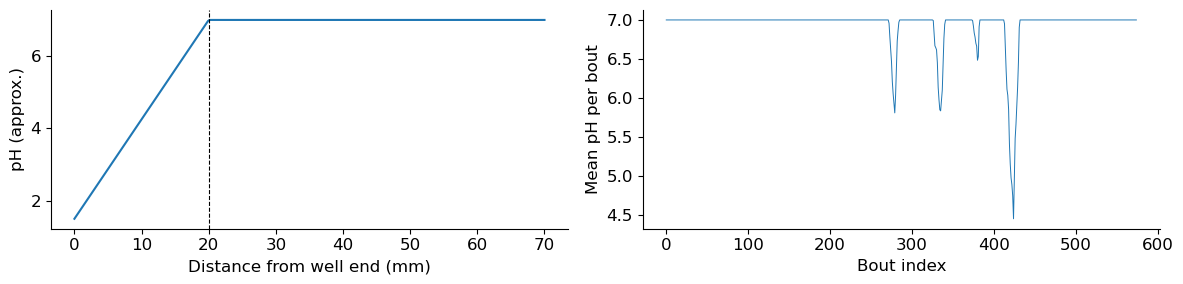

In [31]:
# ── pH gradient profile ───────────────────────────────────────────────────────
dist_grid = np.linspace(0, arena_len_mm / 2, 300)
ph_grid   = np.clip(1.5 + (7.0 - 1.5) * dist_grid / gradient_len_mm, 1.5, 7.0)

# ── one fish: mean pH per bout over time ──────────────────────────────────────
exp0 = df['experiment'].unique()[0]
grp0 = df[(df['experiment'] == exp0) & (df['well_idx'] == 0)].sort_values('bout_start')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(dist_grid, ph_grid)
axes[0].axvline(gradient_len_mm, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('Distance from well end (mm)')
axes[0].set_ylabel('pH (approx.)')

axes[1].plot(grp0['mean_ph'].values, lw=0.7)
axes[1].set_xlabel('Bout index')
axes[1].set_ylabel('Mean pH per bout')

plt.tight_layout()
# plt.savefig('fig_gradient_bouts.pdf', bbox_inches='tight')

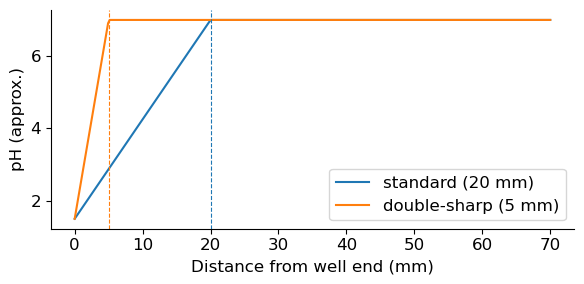

In [32]:
# ── double-sharp gradient profile ─────────────────────────────────────────────
# The double-sharp condition has a narrower acid zone at each end of the arena.
# Adjust gradient_len_mm_sharp to match the actual experimental parameterization.
gradient_len_mm_sharp = 5.0

ph_grid_sharp = np.clip(1.5 + (7.0 - 1.5) * dist_grid / gradient_len_mm_sharp, 1.5, 7.0)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(dist_grid, ph_grid,       label=f'standard ({gradient_len_mm:.0f} mm)')
ax.plot(dist_grid, ph_grid_sharp, label=f'double-sharp ({gradient_len_mm_sharp:.0f} mm)')
ax.axvline(gradient_len_mm,       color='C0', lw=0.8, ls='--')
ax.axvline(gradient_len_mm_sharp, color='C1', lw=0.8, ls='--')
ax.set_xlabel('Distance from well end (mm)')
ax.set_ylabel('pH (approx.)')
ax.legend()
plt.tight_layout()
# plt.savefig('fig_gradient_sharp.pdf', bbox_inches='tight')

## 2. Kinematic features and clustering

In [33]:
# keep bouts of reasonable length
df = df[df['n_frames'].between(8, 200)].reset_index(drop=True)
print(f'{len(df):,} bouts after length filter')


165,438 bouts after length filter


In [ ]:
# cluster bouts and plot clusters - original paper used GMM with 5 clusters

## 3. Build per-fish bout sequences

In [ ]:
# Welltype key (Reddy et al.):
#   0  -- exploratory (no gradient, control)
#   1  -- acid on left        -1 -- acid on right
#   2  -- homogeneous pH       3 -- double sharp pH
#   4  -- bad data             5 -- paramecia        6 -- paramecia_explo
#
# Within each experiment file:
#   well_idx  0–5  → exploratory (welltype 0)
#   well_idx  6–11 → pH gradient (welltype 1, -1, 2, or 3)

print('Experiment × wells:')
for e in sorted(df['experiment'].unique()):
    wells = sorted(df[df['experiment'] == e]['well_idx'].unique())
    print(f'  {e}   wells {wells[0]}–{wells[-1]}')

# ── YOUR CODE ─────────────────────────────────────────────────────────────────
# Choose an experiment and well index, then extract the bout sequence and input signal.
# exp_name = ...
# well_idx = ...
# grp   = df[(df['experiment'] == exp_name) & (df['well_idx'] == well_idx)].sort_values('bout_start')
# seq   = grp['cluster'].values.astype(int)
# u_raw = grp['mean_ph'].values
# u_seq = (u_raw - u_raw.mean()) / (u_raw.std() + 1e-8)

In [ ]:
# ── Optional: build a second sequence for comparison ─────────────────────────
# e.g. a control fish (well_idx 0–5) vs. a gradient fish (well_idx 6–11),
# or two fish from the same condition.
# well_ctrl = ...
# grp_ctrl  = df[(df['experiment'] == exp_name) & (df['well_idx'] == well_ctrl)].sort_values('bout_start')
# seq_ctrl   = grp_ctrl['cluster'].values.astype(int)
# u_raw_ctrl = grp_ctrl['mean_ph'].values
# u_ctrl     = (u_raw_ctrl - u_raw_ctrl.mean()) / (u_raw_ctrl.std() + 1e-8)

## 4. Fit custom HMM



In [ ]:
# K_out = ...

# ── YOUR CODE ─────────────────────────────────────────────────────────────────
# model = ssm.HMM(K_out, 1, M=1, transitions='inputdriven')
# model.observations = CategoricalARObservations(K_out, 1, C=K_in)
# lls = model.fit(seq[:, None], inputs=u_seq[:, None], method='em', num_iters=100)
# print(f'Log-likelihood: {lls[0]:.1f} → {lls[-1]:.1f}')

## 5. Evaluate

In [ ]:
# ── YOUR CODE ─────────────────────────────────────────────────────────────────
# z_hat    = model.most_likely_states(seq[:, None], input=u_seq[:, None])
# A_in_fit = np.exp(model.observations.logAs)   # (K_out, K_in, K_in)
# W_fit    = model.transitions.Ws               # (K_out, 1)
#
# Plot: EM log-likelihood curve, input weights W, A_in matrices, and
# a timeseries of mean pH + inferred mode z_hat.